CAPSTON PROJECT  
Class : INFO-6147 Deep Learning with Pytorch  
Professor : M. Yousefhussien  
Program : AIM1  
Student ID :1319840  
Student Name : Seongmin Choi

In [1]:
# Import required modules
import torch
import torch.nn as nn
from torchvision.models import resnet50
from torchvision import transforms as T 
import requests # for loading images from web
from PIL import Image # for viewing images
import matplotlib.pyplot as plt

detr = torch.hub.load('facebookresearch/detr',
                      'detr_resnet50',
                       pretrained=True)

Using cache found in C:\Users\csm02/.cache\torch\hub\facebookresearch_detr_main
c:\Users\csm02\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\csm02\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:

class SimpleDETR(nn.Module):
   """
   Minimal Example of the Detection Transformer model with learned positional embedding
   """
   def __init__(self, num_classes, hidden_dim, num_heads,
               num_enc_layers, num_dec_layers):
      super(SimpleDETR, self).__init__()
      self.num_classes = num_classes
      self.hidden_dim = hidden_dim
      self.num_heads = num_heads
      self.num_enc_layers = num_enc_layers
      self.num_dec_layers = num_dec_layers
      # CNN Backbone
      self.backbone = nn.Sequential(
            *list(resnet50(pretrained=True).children())[:-2])
      self.conv = nn.Conv2d(2048, hidden_dim, 1)
      # Transformer
      self.transformer = nn.Transformer(hidden_dim, num_heads,
            num_enc_layers, num_dec_layers)
      # Prediction Heads
      self.to_classes = nn.Linear(hidden_dim, num_classes+1)
      self.to_bbox = nn.Linear(hidden_dim, 4)
      # Positional Encodings
      self.object_query = nn.Parameter(torch.rand(100, hidden_dim))
      self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
      self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
   def forward(self, X):
      X = self.backbone(X)
      h = self.conv(X)
      H, W = h.shape[-2:]
      pos_enc = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H,1,1),
            self.row_embed[:H].unsqueeze(1).repeat(1,W,1)],
         dim=-1).flatten(0,1).unsqueeze(1)
      h = self.transformer(pos_enc + h.flatten(2).permute(2,0,1),
      self.object_query.unsqueeze(1))
      class_pred = self.to_classes(h)
      bbox_pred = self.to_bbox(h).sigmoid()
      
      return class_pred, bbox_pred

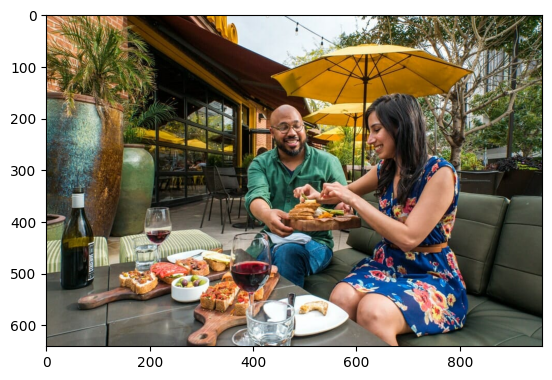

In [3]:
url = 'https://www.tempetourism.com/wp-content/uploads/Postino-Downtown-Tempe-2.jpg' # Sample image
image = Image.open(requests.get(url, stream=True).raw) 
plt.imshow(image)
plt.show()

In [4]:
transform = T.Compose([T.Resize(800),
                       T.ToTensor(),
                       T.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225])])

CLASSES = ['N/A', 'Person', 'Bicycle', 'Car', 'Motorcycle', 'Airplane', 'Bus', 'Train', 'Truck', 'Boat', 
           'Traffic-Light', 'Fire-Hydrant', 'N/A', 'Stop-Sign', 'Parking Meter', 'Bench', 'Bird', 'Cat', 'Dog', 'Horse', 
           'Sheep', 'Cow', 'Elephant', 'Bear', 'Zebra', 'Giraffe', 'N/A', 'Backpack', 'Umbrella', 'N/A', 
           'N/A', 'Handbag', 'Tie', 'Suitcase', 'Frisbee', 'Skis', 'Snowboard', 'Sports-Ball', 'Kite', 'Baseball Bat', 
           'Baseball Glove', 'Skateboard', 'Surfboard', 'Tennis Racket', 'Bottle', 'N/A', 'Wine Glass', 'Cup', 'Fork', 'Knife', 
           'Spoon', 'Bowl', 'Banana', 'Apple', 'Sandwich', 'Orange', 'Broccoli', 'Carrot', 'Hot-Dog', 'Pizza', 
           'Donut', 'Cake', 'Chair', 'Couch', 'Potted Plant', 'Bed', 'N/A', 'Dining Table', 'N/A','N/A', 
           'Toilet', 'N/A', 'TV', 'Laptop', 'Mouse', 'Remote', 'Keyboard', 'Cell-Phone', 'Microwave', 'Oven', 
           'Toaster', 'Sink', 'Refrigerator', 'N/A', 'Book', 'Clock', 'Vase', 'Scissors', 'Teddy-Bear', 'Hair-Dryer', 'Toothbrush',
           'Edodo']

COLORS = [
    [0.000, 0.447, 0.741], 
    [0.850, 0.325, 0.098], 
    [0.929, 0.694, 0.125],
    [0.494, 0.184, 0.556],
    [0.466, 0.674, 0.188],
    [0.301, 0.745, 0.933]  
]

# Get coordinates (x0, y0, x1, y0) from model output (x, y, w, h)
def get_box_coords(boxes):
    x, y, w, h = boxes.unbind(1)
    x0, y0 = (x - 0.5 * w), (y - 0.5 * h)
    x1, y1 = (x + 0.5 * w), (y + 0.5 * h)
    box = [x0, y0, x1, y1]
    return torch.stack(box, dim=1)

# Scale box from [0,1]x[0,1] to [0, width]x[0, height]
def scale_boxes(output_box, width, height):
    box_coords = get_box_coords(output_box)
    scale_tensor = torch.Tensor(
                 [width, height, width, height]).to(
                 torch.cuda.current_device())
    return box_coords * scale_tensor

# Object Detection Pipeline
def detect(im, model, transform):
    device = torch.cuda.current_device()
    width = im.size[0]
    height = im.size[1]
   
    # mean-std normalize the input image (batch-size: 1)
    img = transform(im).unsqueeze(0)
    img = img.to(device)
    
    # demo model only support by default images with aspect ratio    between 0.5 and 2
    img.shape[-2] <= 1600 and img.shape[-1] <= 1600,
    # propagate through the model
    outputs = model(img)
    # keep only predictions with 0.7+ confidence
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.85
   
    # convert boxes from [0; 1] to image scales
    bboxes_scaled = scale_boxes(outputs['pred_boxes'][0, keep], width, height)
    return probas[keep], bboxes_scaled

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
detr.to(device)
probs, bboxes = detect(image, detr, transform)
# Plot Predicted Bounding Boxes
def plot_results(pil_img, prob, boxes,labels=True):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    
    for prob, (x0, y0, x1, y1), color in zip(prob, boxes.tolist(),   COLORS * 100):
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,  
             fill=False, color=color, linewidth=2))
        cl = prob.argmax()
        text = f'{CLASSES[cl]}: {prob[cl]:0.2f}'
        if labels:
            ax.text(x0, y0, text, fontsize=15,
                bbox=dict(facecolor=color, alpha=0.75))
    plt.axis('off')
    plt.show()

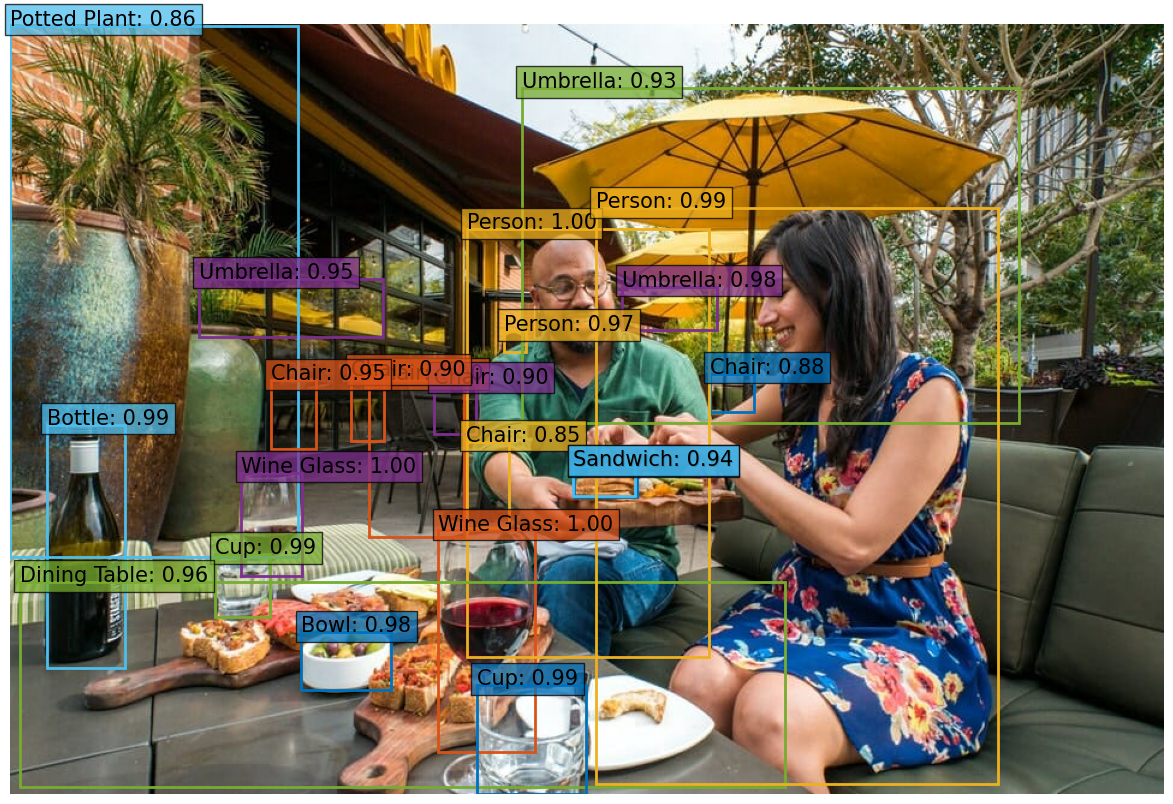

In [5]:
plot_results(image, probs, bboxes, labels=True)

### Dataset & Loader

In [6]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class EdodoDataset(Dataset):
    def __init__(self, img_dir, anno_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        # load_annotations 
        self.annotations = self.load_annotations(anno_file) 

    def load_annotations(self, anno_file):
        # load json file
        with open(anno_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return data

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        img_info = self.annotations[idx]
        
        # 1. Load Image
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        
        # 2. Convert to Tensors
        # boxes 형식: [[x, y, w, h], ...]
        boxes = torch.as_tensor(img_info['boxes'], dtype=torch.float32)
        labels = torch.as_tensor(img_info['labels'], dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels
        }

        # 3. Resize, Normalize
        if self.transform:
            image = self.transform(image)

        return image, target

# data loader
dataset = EdodoDataset(
    img_dir='./trainImg/',      # train image folder containing files like 01 edodo.jpg
    anno_file='./trainImg/annotations.json', 
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

### Prepare Model

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare the model and modify the output layer
num_classes = 92 # 91 COCO classes + 1 Edodo class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep the weights of the existing model and extend only the final layer
model = detr 
model.to(device)

# 2. Configure the optimizer
# AdamW is the recommended optimizer in the DETR paper.
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 3. Loss function (Simplified version)
# Although the original DETR uses a Hungarian Matcher, we set up 
# Classification (CrossEntropy) and Box Error (MSE) as basics for training with 10 images.
criterion = nn.CrossEntropyLoss() 
bbox_criterion = nn.MSELoss()

print(f"Ready for training (Device: {device})")

Ready for training (Device: cuda)


### Model Training

In [8]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Pre-trained
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# 2. Class count (ex: Edodo 1 + background 1 = 2)
num_classes = 92 
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

In [9]:
epochs = 30
model.train()
import os
# cuba debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

for epoch in range(epochs):
    epoch_loss = 0
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        
        corrected_targets = []
        for t in targets:
            boxes = t['boxes'].to(device, dtype=torch.float32)
            
            
            # 1. x_max > x_min, y_max > y_min check and correction
            invalid_boxes = (boxes[:, 2] <= boxes[:, 0]) | (boxes[:, 3] <= boxes[:, 1])
            if invalid_boxes.any():
                # problems with boxes will cause training to fail, so we need to fix them.
                boxes[invalid_boxes, 2] = boxes[invalid_boxes, 0] + 1
                boxes[invalid_boxes, 3] = boxes[invalid_boxes, 1] + 1

            # 2. Ensure labels are correct
            labels = torch.ones((boxes.shape[0],), dtype=torch.int64).to(device)
            
            corrected_targets.append({'boxes': boxes, 'labels': labels})

        # 
        try:
            loss_dict = model(images, corrected_targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            epoch_loss += losses.item()
        except RuntimeError as e:
            print(f"Error occurred: {e}")
            continue # 

print("Training complete! 'Edodo' detection model is ready.")

Training complete! 'Edodo' detection model is ready.


#### Model Save


In [10]:
# 4. Model save
save_path = 'detr_edodo_final.pth'
torch.save(model.state_dict(), save_path)
print(f"SavePath: {save_path}")

# 5. Model Test
model.eval()

print("Model weights saved successfully!")

SavePath: detr_edodo_final.pth
Model weights saved successfully!
